# Malaria Burden & Intervention Effectiveness Analysis
## Notebook 02 — Exploratory Data Analysis

**Author:** Stephen Udoh
**Date:** June 2026
**GitHub:** github.com/Stephen-Udoh/malaria-analysis

---

### Purpose
Explore the structure, distribution, and relationships in both
analytical tables before any formal statistical testing.
Good EDA prevents bad analysis — patterns seen here shape
every modelling decision in Notebooks 03 and 04.

---

### This notebook covers
1. Setup and data loading
2. Descriptive statistics — both analytical tables
3. Distribution analysis — normality, skewness, outliers
4. Time series — how malaria burden changed 2000–2024
5. Correlation analysis — relationships between variables
6. Sub-regional comparisons — where is burden highest?
7. ITN scale-up patterns — which countries improved most?
8. Key findings summary — what the data shows before modelling

## 1. Setup and Data Loading

In [1]:
# Standard imports for exploratory analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
import os

warnings.filterwarnings('ignore')

# Consistent visual style across all charts
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi']      = 150
plt.rcParams['figure.figsize']  = (12, 5)
plt.rcParams['font.family']     = 'DejaVu Sans'

print("✓ Libraries loaded successfully")

✓ Libraries loaded successfully


In [2]:
# Load both analytical tables from cleaned data folder
# All analysis in this notebook runs from these two DataFrames

CLEANED_PATH = os.path.join(os.path.dirname(os.getcwd()), 'data', 'cleaned')

trend_df      = pd.read_csv(os.path.join(CLEANED_PATH, 'trend_data.csv'))
regression_df = pd.read_csv(os.path.join(CLEANED_PATH, 'regression_data.csv'))

print(f"✓ trend_data      loaded — {trend_df.shape[0]:,} rows, {trend_df.shape[1]} columns")
print(f"✓ regression_data loaded — {regression_df.shape[0]:,} rows, {regression_df.shape[1]} columns")

✓ trend_data      loaded — 1,123 rows, 11 columns
✓ regression_data loaded — 371 rows, 10 columns


## 2. Descriptive Statistics

Summary statistics for both analytical tables.
Provides baseline understanding of variable ranges,
central tendency, and spread before visualisation.

In [3]:
# Descriptive statistics for trend_data
# Covers the full 2000-2024 burden and economic variables

print("=== trend_data descriptive statistics ===\n")
print(trend_df.describe().round(2).to_string())

=== trend_data descriptive statistics ===

          year  incidence_per_1000  incidence_low  incidence_high  mortality_per_100k  mortality_low  mortality_high  gdp_per_capita  urban_pct
count  1123.00             1123.00        1122.00         1122.00             1122.00        1121.00         1121.00         1071.00    1101.00
mean   2012.04              217.46         155.75          299.42               61.75          54.52           71.79         1835.65      40.71
std       7.20              157.70         122.31          208.38               58.69          55.27           63.25         2261.60      17.41
min    2000.00                0.00           0.00            0.00                0.00           0.00            0.00          109.59       8.04
25%    2006.00               62.16          31.75           88.52               17.24           6.73           23.05          533.82      27.04
50%    2012.00              238.87         164.71          335.49               45.65        

In [4]:
# Descriptive statistics for regression_data
# Covers 2015-2024 with all predictor and outcome variables

print("=== regression_data descriptive statistics ===\n")
print(regression_df.describe().round(2).to_string())

=== regression_data descriptive statistics ===

          year  incidence_per_1000  mortality_per_100k  itn_coverage_pct  irs_deployed  act_deployed  gdp_per_capita  urban_pct
count   371.00              371.00              371.00            370.00        371.00        371.00          352.00     371.00
mean   2019.50              225.67               50.72             54.95          0.51          0.62         1578.58      41.53
std       2.87              117.52               32.21             18.56          0.50          0.49         1647.66      16.76
min    2015.00                0.00                0.00              5.13          0.00          0.00          219.42      14.67
25%    2017.00              109.68               24.50             42.26          0.00          0.00          713.96      29.33
50%    2020.00              254.08               43.66             59.61          1.00          1.00          998.02      40.58
75%    2022.00              314.01               73.31  

### Key observations from descriptive statistics

- Incidence ranges from 0 to 711 per 1,000 — extreme variation across countries
- Mortality ranges from 0 to 374 per 100,000 — similarly wide spread
- ITN coverage ranges from 5% to 95% — sufficient variation for regression
- GDP per capita highly right-skewed (std ≈ mean) — log transformation required
- IRS deployed in ~51% of country-years, ACT in ~62%
- High standard deviations throughout confirm sub-Saharan Africa 
  is not a homogeneous region — country-level differences are large

## 3. Distribution Analysis

Visual inspection of variable distributions.
Identifies skewness, outliers, and transformation needs
before formal statistical testing.

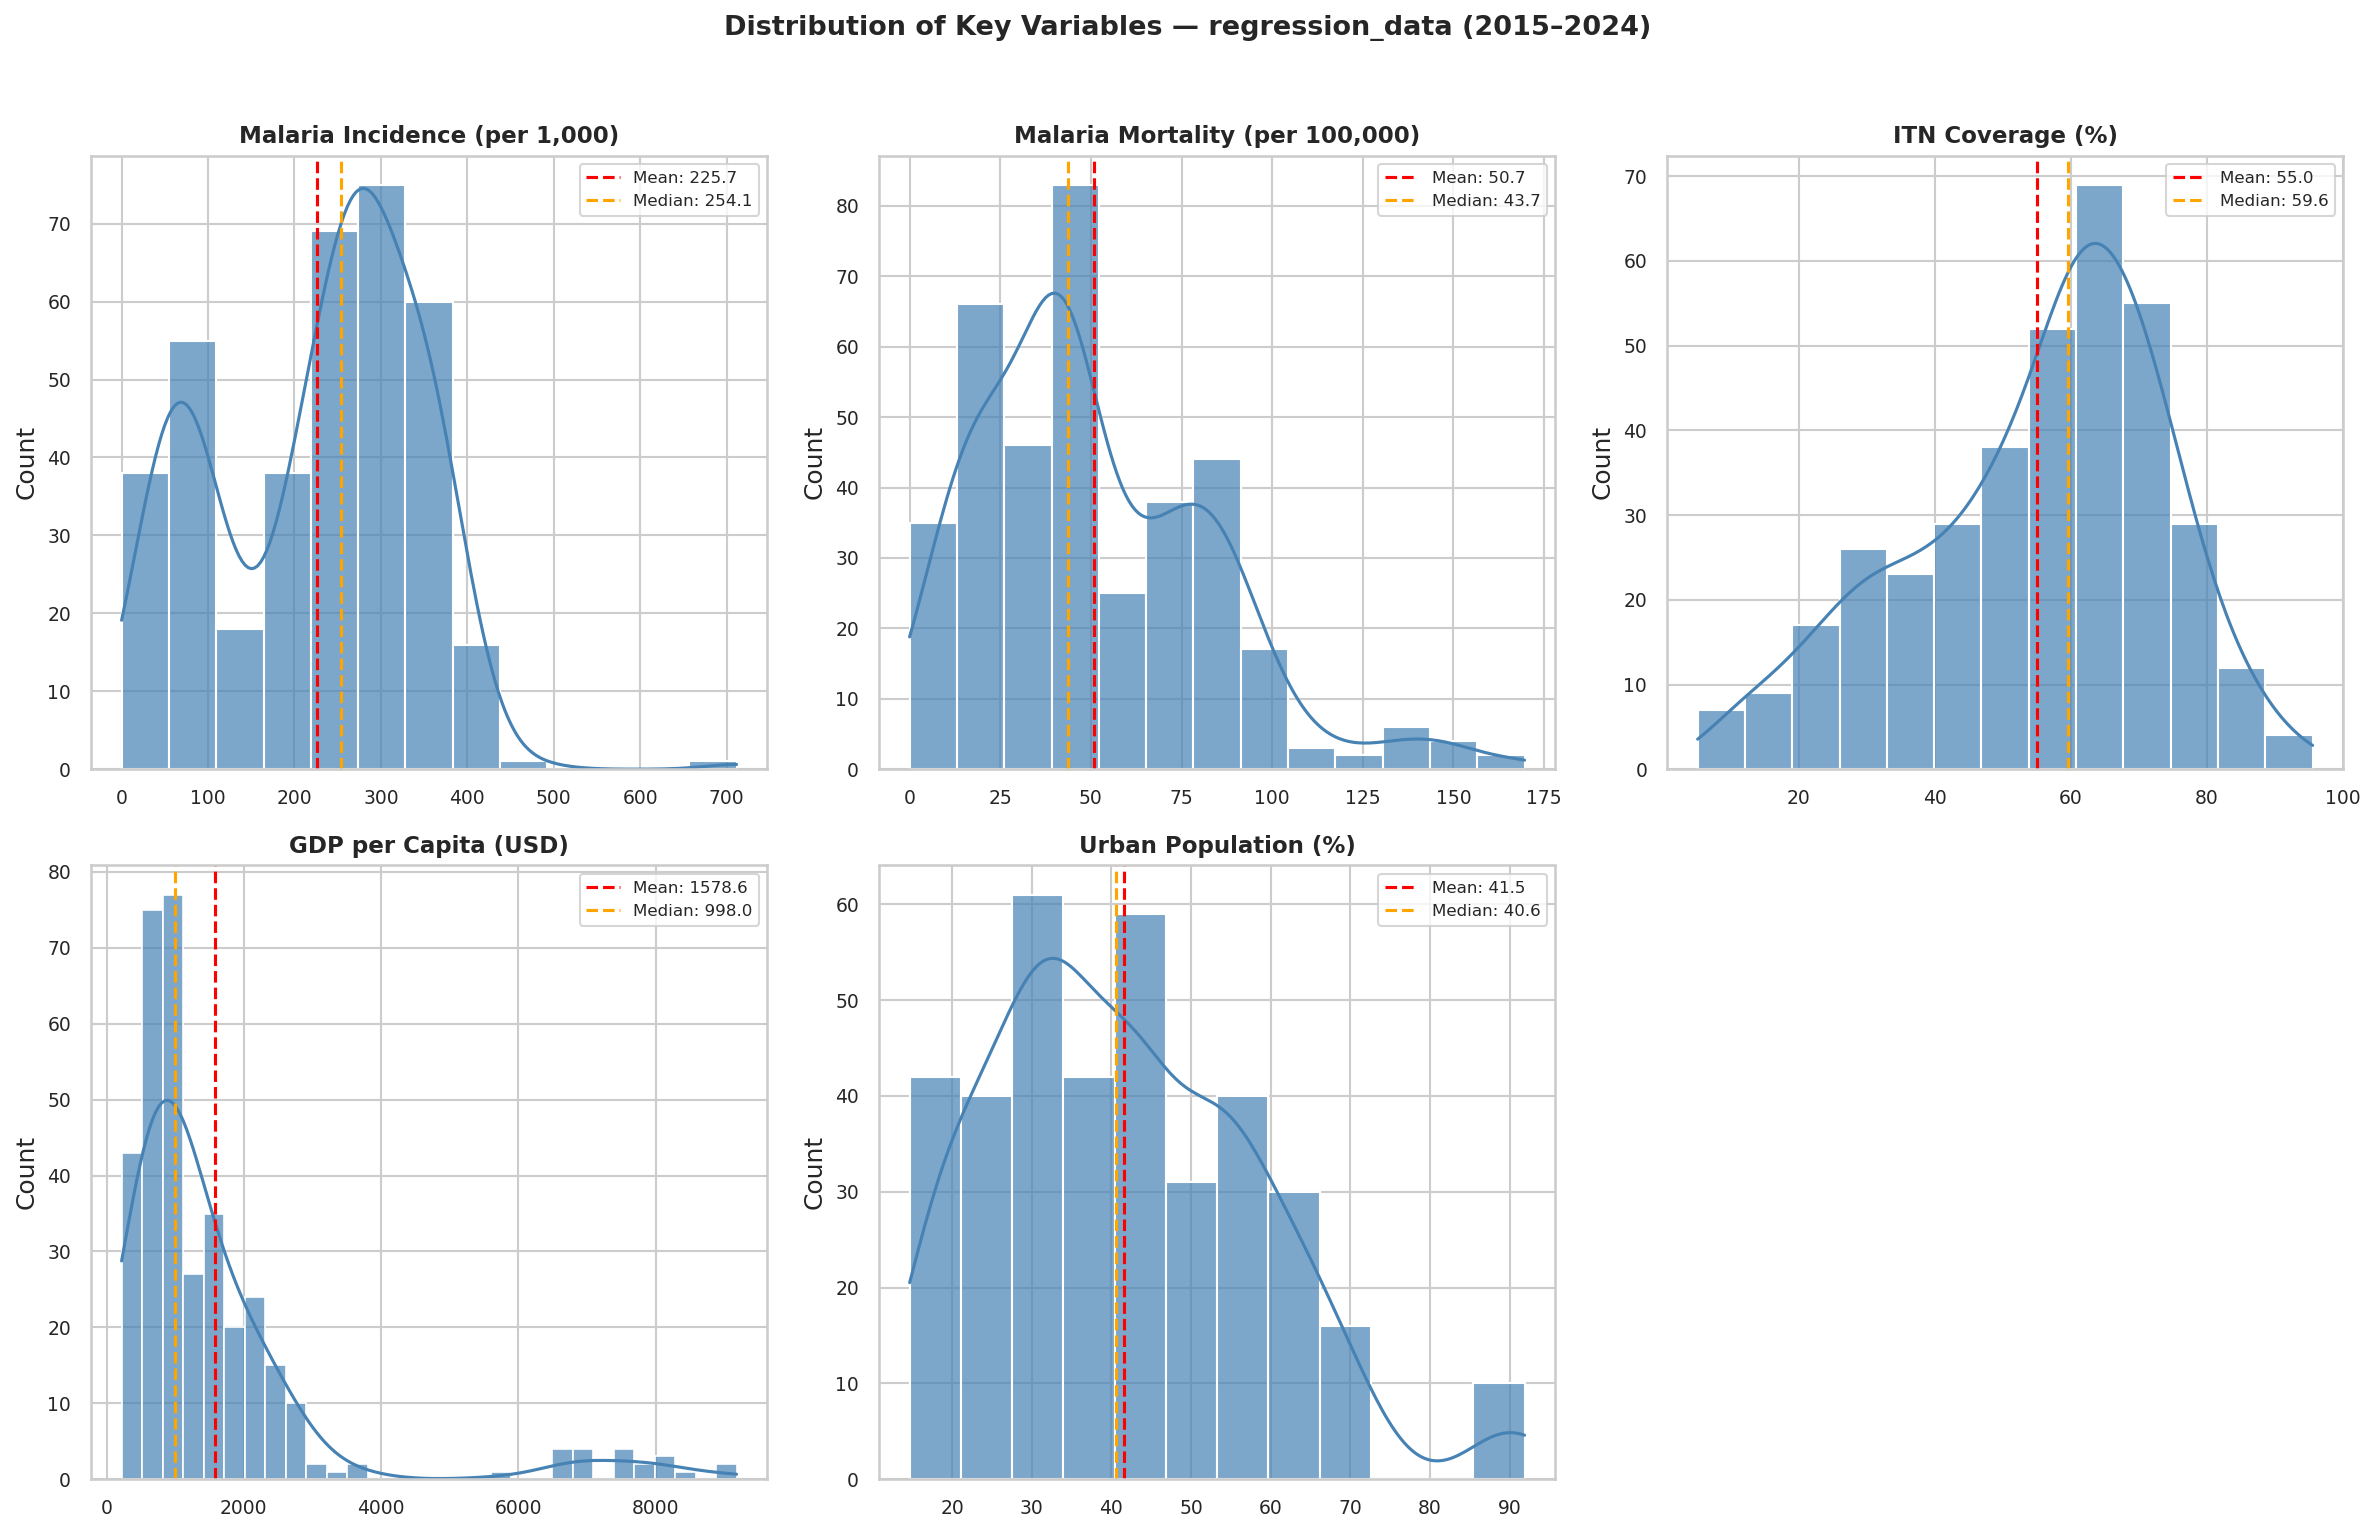

✓ Chart saved to /outputs/figures/


In [5]:
# Distribution plots for all continuous variables in regression_data
# Histogram with KDE overlay shows shape clearly
# Red dashed line marks the mean

continuous_vars = {
    'incidence_per_1000' : 'Malaria Incidence (per 1,000)',
    'mortality_per_100k' : 'Malaria Mortality (per 100,000)',
    'itn_coverage_pct'   : 'ITN Coverage (%)',
    'gdp_per_capita'     : 'GDP per Capita (USD)',
    'urban_pct'          : 'Urban Population (%)'
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (col, label) in enumerate(continuous_vars.items()):
    ax = axes[idx]
    
    data = regression_df[col].dropna()
    
    # Histogram with KDE
    sns.histplot(data, kde=True, ax=ax, color='steelblue', alpha=0.7)
    
    # Mean line
    ax.axvline(data.mean(), color='red', linestyle='--', 
               linewidth=1.5, label=f'Mean: {data.mean():.1f}')
    
    # Median line
    ax.axvline(data.median(), color='orange', linestyle='--',
               linewidth=1.5, label=f'Median: {data.median():.1f}')
    
    ax.set_title(label, fontweight='bold', fontsize=11)
    ax.set_xlabel('')
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=9)

# Hide unused subplot
axes[-1].set_visible(False)

plt.suptitle('Distribution of Key Variables — regression_data (2015–2024)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()

# Save to outputs folder
OUTPUT_PATH = os.path.join(os.path.dirname(os.getcwd()), 'outputs', 'figures')
os.makedirs(OUTPUT_PATH, exist_ok=True)
plt.savefig(os.path.join(OUTPUT_PATH, '01_variable_distributions.png'),
            bbox_inches='tight', dpi=150)

plt.show()
print("✓ Chart saved to /outputs/figures/")

### Distribution findings

- **GDP per capita** — severely right-skewed, log transformation required before regression
- **Malaria mortality** — right-skewed, formal normality test needed
- **Malaria incidence** — moderate skew with zero-value spike from low-burden countries
- **ITN coverage** — approximately normal, left-skewed, no transformation needed
- **Urban population** — bimodal distribution suggesting two distinct country groups

## 3.1 Normality Testing

Shapiro-Wilk test for normality on all continuous variables.
Results inform transformation decisions before regression.
p < 0.05 indicates significant departure from normality.

In [6]:
from scipy.stats import shapiro, skew, kurtosis

print("Normality Tests — Shapiro-Wilk\n")
print(f"{'Variable':<25} {'Skewness':>10} {'Kurtosis':>10} {'W-stat':>10} {'p-value':>12} {'Normal?':>10}")
print("-" * 80)

for col, label in continuous_vars.items():
    data = regression_df[col].dropna()
    
    sk        = skew(data)
    kurt      = kurtosis(data)
    stat, p   = shapiro(data)
    normal    = "Yes" if p > 0.05 else "No"
    
    print(f"{label:<25} {sk:>10.3f} {kurt:>10.3f} {stat:>10.4f} {p:>12.6f} {normal:>10}")

Normality Tests — Shapiro-Wilk

Variable                    Skewness   Kurtosis     W-stat      p-value    Normal?
--------------------------------------------------------------------------------
Malaria Incidence (per 1,000)     -0.168     -0.437     0.9415     0.000000         No
Malaria Mortality (per 100,000)      0.893      0.818     0.9418     0.000000         No
ITN Coverage (%)              -0.544     -0.336     0.9656     0.000000         No
GDP per Capita (USD)           2.868      8.198     0.6215     0.000000         No
Urban Population (%)           0.627      0.152     0.9594     0.000000         No


### Normality test interpretation

Shapiro-Wilk p-values are significant for all variables — expected 
with n=370. W-statistics and skewness coefficients are more informative.

| Variable | W-stat | Skewness | Decision |
|----------|--------|----------|----------|
| Incidence | 0.942 | -0.17 | Retain as-is — acceptable skew |
| Mortality | 0.942 | 0.89 | Retain — borderline, monitor |
| ITN coverage | 0.966 | -0.54 | Retain as-is — near normal |
| GDP per capita | 0.622 | 2.87 | Log-transform required |
| Urban % | 0.959 | 0.63 | Retain as-is — acceptable |

GDP transformation comparison:

Metric                 Original    Log-transformed
--------------------------------------------------
Skewness                  2.868              0.659
W-statistic              0.6215             0.9582
p-value                0.000000           0.000000


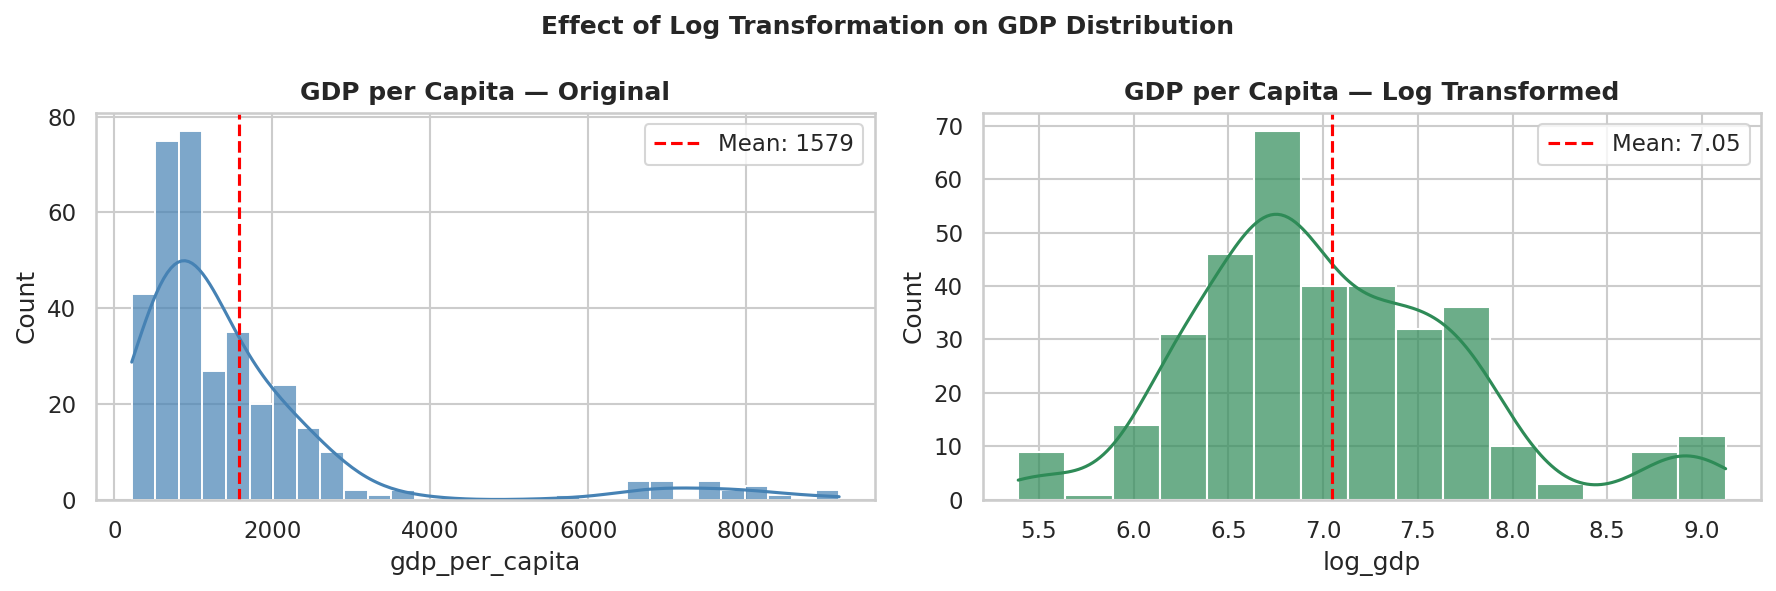

✓ Chart saved


In [7]:
# Apply log transformation to GDP per capita
# Evidence: skewness = 2.87, W-statistic = 0.62
# Log transformation compresses the right tail
# making the distribution more symmetric

regression_df['log_gdp'] = np.log(regression_df['gdp_per_capita'])
trend_df['log_gdp']      = np.log(trend_df['gdp_per_capita'])

# Verify transformation improved normality
gdp_data     = regression_df['gdp_per_capita'].dropna()
log_gdp_data = regression_df['log_gdp'].dropna()

stat_raw, p_raw     = shapiro(gdp_data)
stat_log, p_log     = shapiro(log_gdp_data)
skew_raw            = skew(gdp_data)
skew_log            = skew(log_gdp_data)

print("GDP transformation comparison:\n")
print(f"{'Metric':<15} {'Original':>15} {'Log-transformed':>18}")
print("-" * 50)
print(f"{'Skewness':<15} {skew_raw:>15.3f} {skew_log:>18.3f}")
print(f"{'W-statistic':<15} {stat_raw:>15.4f} {stat_log:>18.4f}")
print(f"{'p-value':<15} {p_raw:>15.6f} {p_log:>18.6f}")

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(gdp_data,     kde=True, ax=axes[0], color='steelblue', alpha=0.7)
axes[0].set_title('GDP per Capita — Original', fontweight='bold')
axes[0].axvline(gdp_data.mean(), color='red', linestyle='--',
                label=f'Mean: {gdp_data.mean():.0f}')
axes[0].legend()

sns.histplot(log_gdp_data, kde=True, ax=axes[1], color='seagreen', alpha=0.7)
axes[1].set_title('GDP per Capita — Log Transformed', fontweight='bold')
axes[1].axvline(log_gdp_data.mean(), color='red', linestyle='--',
                label=f'Mean: {log_gdp_data.mean():.2f}')
axes[1].legend()

plt.suptitle('Effect of Log Transformation on GDP Distribution',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, '02_gdp_log_transformation.png'),
            bbox_inches='tight', dpi=150)
plt.show()
print("✓ Chart saved")

## 4. Time Series Analysis — Malaria Burden 2000–2024

Tracks how malaria incidence and mortality changed across
sub-Saharan Africa over 24 years. Uses trend_data which covers
the full 2000–2024 period for both outcome variables.

Regional aggregation uses population-weighted means where possible.
Unweighted means used here due to absence of population denominators
in the analytical table — noted as limitation.

In [8]:
# Aggregate burden indicators by year across all African countries
# Unweighted mean — each country contributes equally
# Limitation: larger countries should ideally carry more weight

yearly_trend = (
    trend_df
    .groupby('year')
    .agg(
        mean_incidence  = ('incidence_per_1000', 'mean'),
        median_incidence= ('incidence_per_1000', 'median'),
        mean_mortality  = ('mortality_per_100k', 'mean'),
        median_mortality= ('mortality_per_100k', 'median'),
        country_count   = ('country_code',        'nunique')
    )
    .reset_index()
)

print("Yearly aggregated burden — first and last 5 years:\n")
print(pd.concat([yearly_trend.head(), yearly_trend.tail()]).to_string(index=False))

Yearly aggregated burden — first and last 5 years:

 year  mean_incidence  median_incidence  mean_mortality  median_mortality  country_count
 2000      289.847415        347.094216      116.210861        117.260183             44
 2001      291.106765        338.204279      109.376494        109.705383             44
 2002      283.587064        326.041286      102.974399         99.926164             44
 2003      270.290170        298.920589       92.319797         89.308162             45
 2004      260.121741        295.972892       84.566682         76.871829             45
 2020      185.027941        219.626504       42.998622         39.947504             45
 2021      173.933645        209.559267       39.770753         37.965648             46
 2022      175.310170        209.093854       39.630974         37.049900             45
 2023      174.974573        200.024317       37.584066         36.293737             45
 2024      177.742221        206.138095       37.648359   

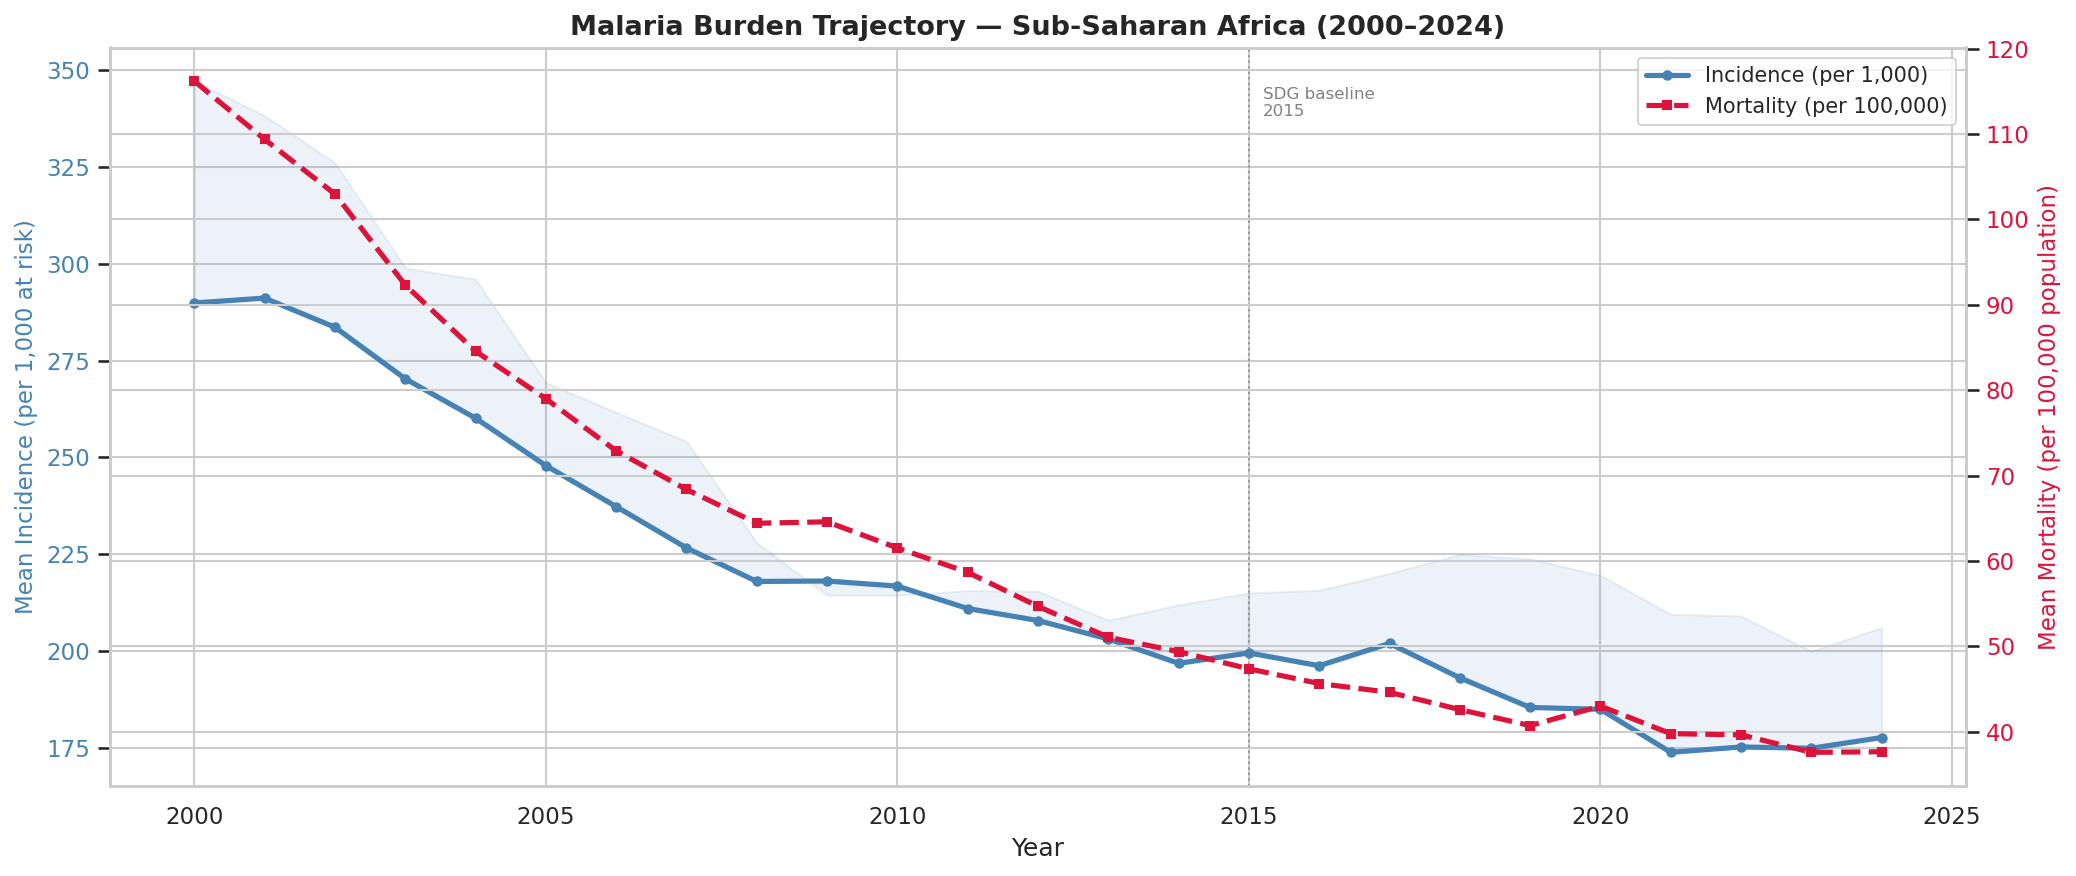

✓ Chart saved


In [9]:
# Time series chart — malaria burden trajectory 2000-2024
# Dual axis: incidence (left) and mortality (right)
# Separate axes because different units and scales

fig, ax1 = plt.subplots(figsize=(14, 6))

# Incidence on left axis
color_inc = 'steelblue'
ax1.plot(yearly_trend['year'], yearly_trend['mean_incidence'],
         color=color_inc, linewidth=2.5, marker='o', markersize=4,
         label='Incidence (per 1,000)')
ax1.fill_between(yearly_trend['year'],
                 yearly_trend['median_incidence'],
                 yearly_trend['mean_incidence'],
                 alpha=0.1, color=color_inc)
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Mean Incidence (per 1,000 at risk)', 
               color=color_inc, fontsize=11)
ax1.tick_params(axis='y', labelcolor=color_inc)

# Mortality on right axis
ax2 = ax1.twinx()
color_mort = 'crimson'
ax2.plot(yearly_trend['year'], yearly_trend['mean_mortality'],
         color=color_mort, linewidth=2.5, marker='s', markersize=4,
         linestyle='--', label='Mortality (per 100,000)')
ax2.set_ylabel('Mean Mortality (per 100,000 population)',
               color=color_mort, fontsize=11)
ax2.tick_params(axis='y', labelcolor=color_mort)

# Reference lines for key events
ax1.axvline(2015, color='gray', linestyle=':', alpha=0.7, linewidth=1)
ax1.text(2015.2, ax1.get_ylim()[1]*0.95, 'SDG baseline\n2015',
         fontsize=8, color='gray')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper right', fontsize=10)

plt.title('Malaria Burden Trajectory — Sub-Saharan Africa (2000–2024)',
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, '03_burden_time_series.png'),
            bbox_inches='tight', dpi=150)
plt.show()
print("✓ Chart saved")

### Time series findings

Both malaria incidence and mortality declined substantially 
across sub-Saharan Africa from 2000 to 2024:

- **Incidence** fell from ~290 to ~175 per 1,000 — a 40% reduction
- **Mortality** fell from ~115 to ~40 per 100,000 — a 65% reduction
- Mortality declined faster than incidence — suggests improved 
  treatment access reduced case fatality even as transmission persisted
- Progress slowed after 2015 — consistent with WHO reports of 
  stalling gains in high-burden countries
- 2020–2021 uptick visible — likely reflects COVID-19 disruption 
  to health service delivery
- Widening mean-median gap post-2015 suggests increasing 
  divergence between countries

In [10]:
# Country to sub-region mapping
# WHO AFR region does not have sub-regions in our data
# Using standard geographic groupings for Africa

sub_regions = {
    # West Africa
    'BEN':'West', 'BFA':'West', 'CIV':'West', 'GHA':'West',
    'GIN':'West', 'GMB':'West', 'GNB':'West', 'LBR':'West',
    'MLI':'West', 'MRT':'West', 'NER':'West', 'NGA':'West',
    'SEN':'West', 'SLE':'West', 'TGO':'West', 'GNQ':'West',

    # East Africa
    'BDI':'East', 'COM':'East', 'ETH':'East', 'KEN':'East',
    'MDG':'East', 'MOZ':'East', 'MUS':'East', 'MWI':'East',
    'RWA':'East', 'SSD':'East', 'TZA':'East', 'UGA':'East',
    'ZMB':'East', 'ZWE':'East', 'ERI':'East',

    # Central Africa
    'AGO':'Central', 'CAF':'Central', 'CMR':'Central',
    'COD':'Central', 'COG':'Central', 'GAB':'Central',
    'STP':'Central', 'TCD':'Central',

    # Southern Africa
    'BWA':'Southern', 'LSO':'Southern', 'NAM':'Southern',
    'SWZ':'Southern', 'ZAF':'Southern',

    # North Africa
    'DZA':'North', 'EGY':'North', 'MAR':'North',
    'SDN':'North', 'TUN':'North',
    # Island states — classified by geographic proximity
    'CPV': 'West',      # Cape Verde — West African island state
    'MYT': 'East'      # Mayotte — Indian Ocean, East African territory
}

# Add sub-region to trend_data
trend_df['sub_region'] = trend_df['country_code'].map(sub_regions)

# Aggregate by year and sub-region
regional_trend = (
    trend_df
    .groupby(['year', 'sub_region'])
    .agg(
        mean_incidence = ('incidence_per_1000', 'mean'),
        mean_mortality = ('mortality_per_100k', 'mean')
    )
    .reset_index()
    .dropna(subset=['sub_region'])
)

print("Sub-regions in dataset:")
print(trend_df['sub_region'].value_counts())

Sub-regions in dataset:
sub_region
West        425
East        373
Central     200
Southern    100
North        25
Name: count, dtype: int64


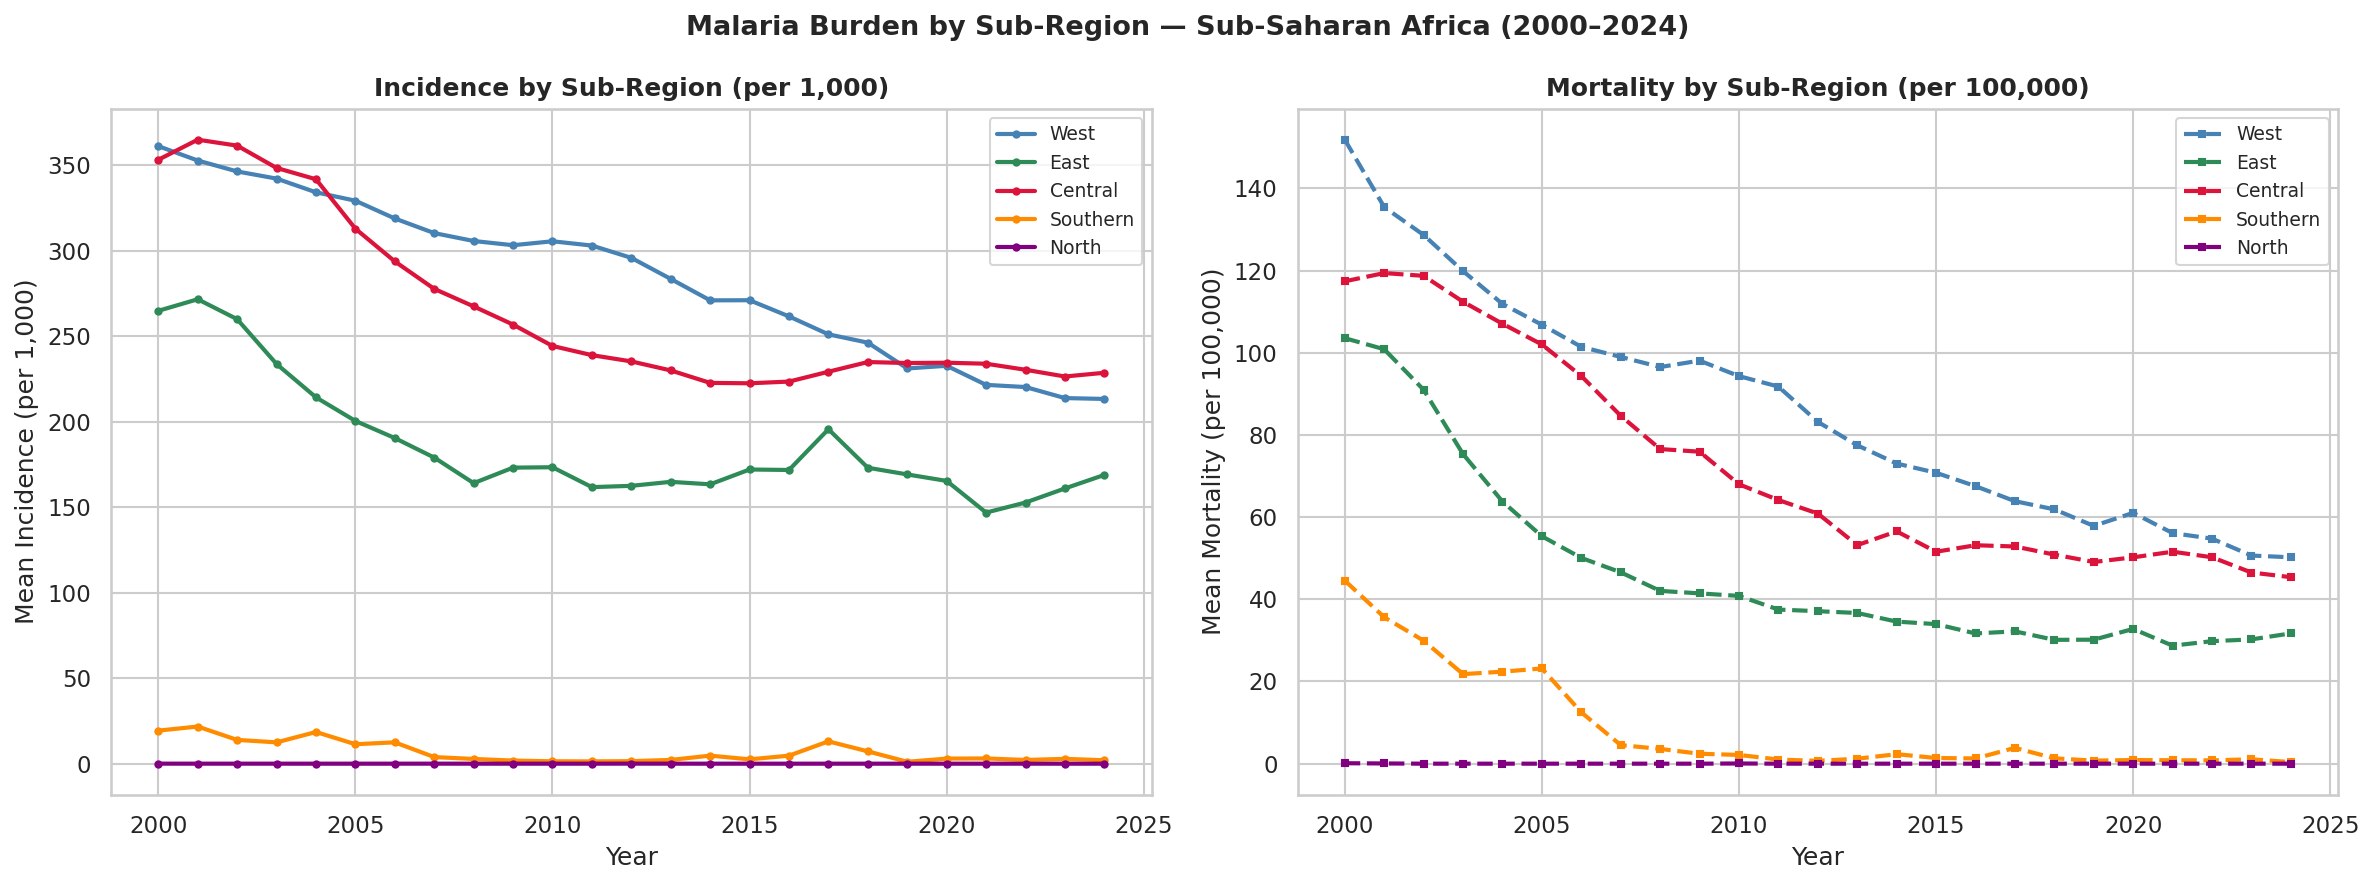

✓ Chart saved


In [11]:
# Regional time series — incidence by sub-region
# Shows whether all regions improved equally or some lagged behind

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

region_colors = {
    'West'    : 'steelblue',
    'East'    : 'seagreen',
    'Central' : 'crimson',
    'Southern': 'darkorange',
    'North'   : 'purple'
}

for region, color in region_colors.items():
    data = regional_trend[regional_trend['sub_region'] == region]
    if len(data) == 0:
        continue

    # Incidence
    axes[0].plot(data['year'], data['mean_incidence'],
                 color=color, linewidth=2, marker='o',
                 markersize=3, label=region)

    # Mortality
    axes[1].plot(data['year'], data['mean_mortality'],
                 color=color, linewidth=2, marker='s',
                 markersize=3, linestyle='--', label=region)

axes[0].set_title('Incidence by Sub-Region (per 1,000)',
                  fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Mean Incidence (per 1,000)')
axes[0].legend(fontsize=9)

axes[1].set_title('Mortality by Sub-Region (per 100,000)',
                  fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Mean Mortality (per 100,000)')
axes[1].legend(fontsize=9)

plt.suptitle('Malaria Burden by Sub-Region — Sub-Saharan Africa (2000–2024)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, '04_regional_burden_trends.png'),
            bbox_inches='tight', dpi=150)
plt.show()
print("✓ Chart saved")

### Regional burden findings

- **West and Central Africa** carry the highest and most persistent 
  malaria burden — still above 200 per 1,000 incidence in 2024
- **East Africa** shows the most consistent decline — aggressive ITN 
  scale-up in Kenya, Uganda, Tanzania and Rwanda likely contributing
- **Southern Africa** achieved near-elimination by 2010 — reflects 
  stronger health systems and economic capacity, not ITN scale-up alone
- **North Africa** effectively malaria-free throughout the period
- Universal regional decline confirms real progress — but West and 
  Central Africa require sustained priority attention
- Regional heterogeneity justifies including sub-region as a 
  control variable in regression analysis

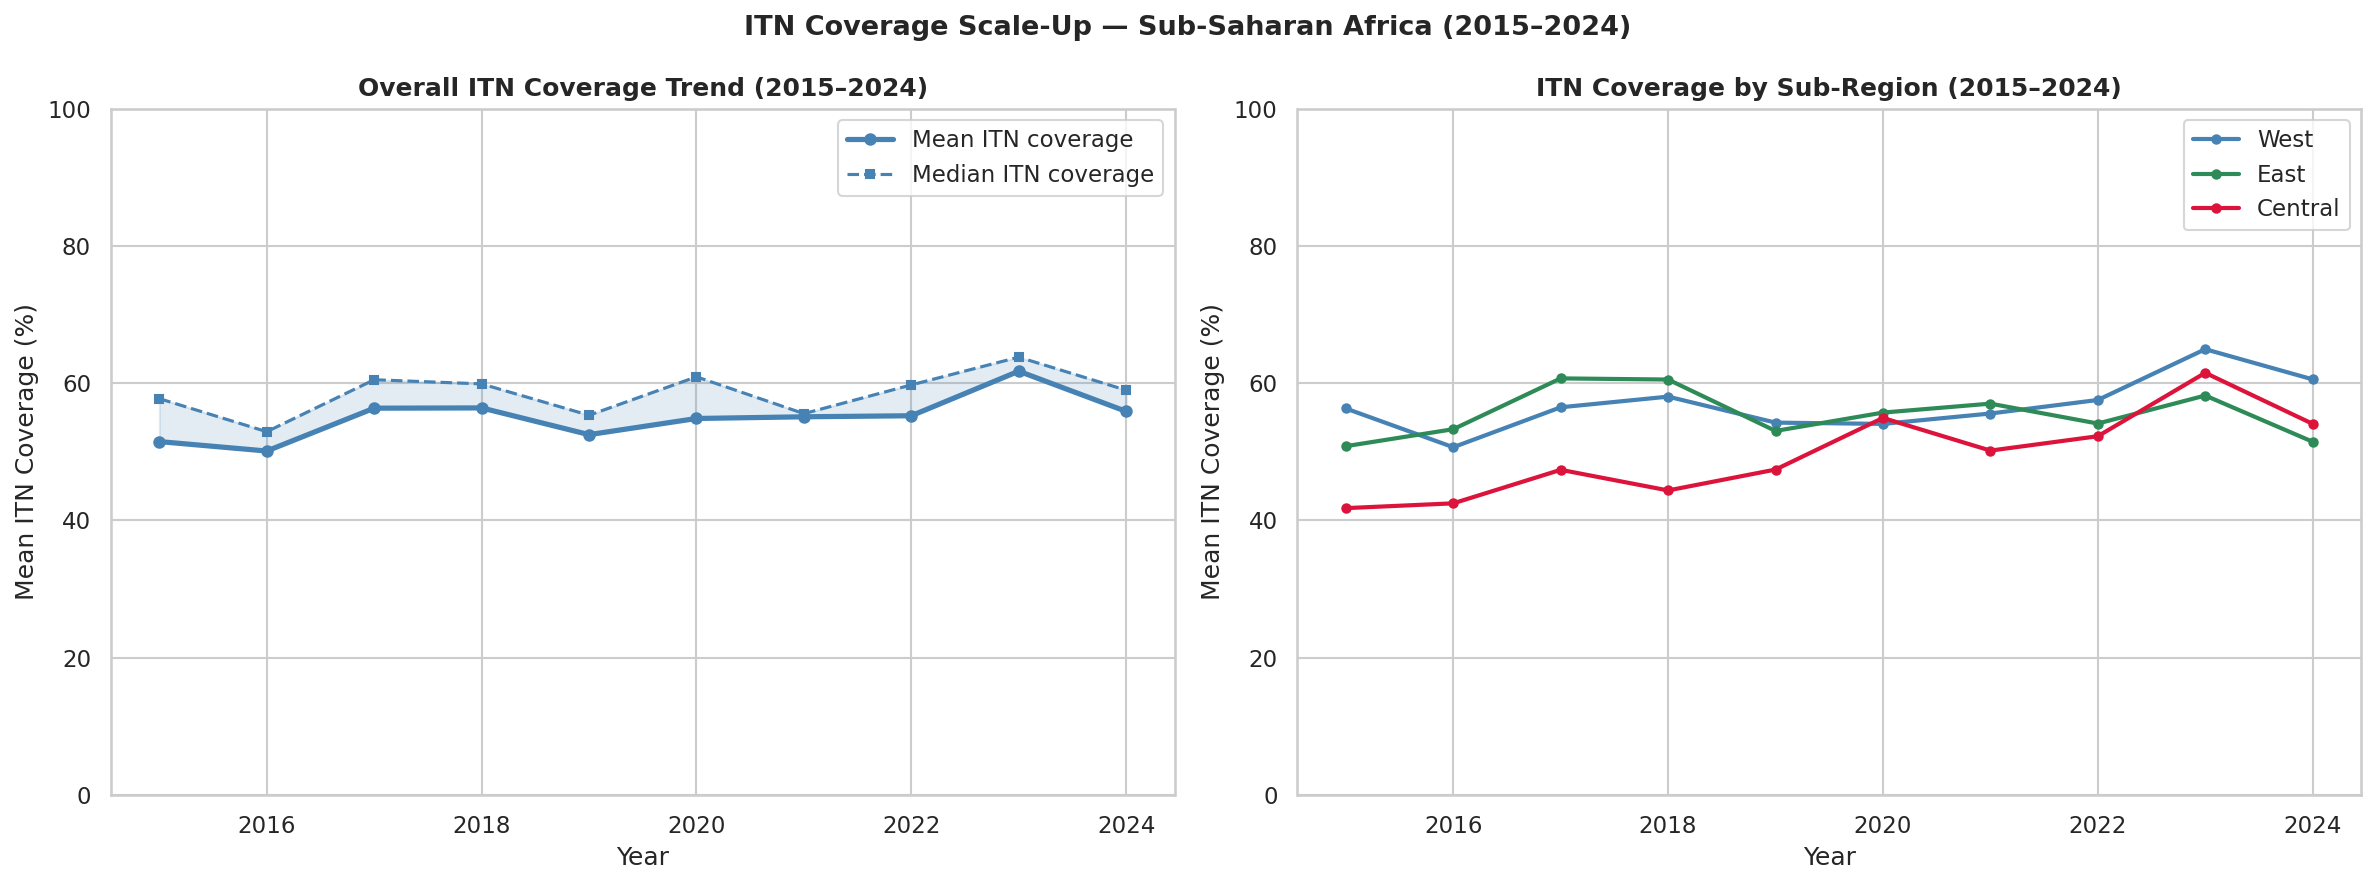

✓ Chart saved


In [12]:
# ITN coverage trajectory 2015-2024
# Shows how the main predictor variable changed over time
# Broken down by sub-region to match burden analysis

# Add sub-region to regression_df
regression_df['sub_region'] = regression_df['country_code'].map(sub_regions)

# Aggregate ITN by year and sub-region
itn_trend = (
    regression_df
    .groupby(['year', 'sub_region'])
    .agg(
        mean_itn    = ('itn_coverage_pct', 'mean'),
        median_itn  = ('itn_coverage_pct', 'median'),
        country_count = ('country_code', 'nunique')
    )
    .reset_index()
    .dropna(subset=['sub_region'])
)

# Overall ITN trend
itn_overall = (
    regression_df
    .groupby('year')
    .agg(
        mean_itn   = ('itn_coverage_pct', 'mean'),
        median_itn = ('itn_coverage_pct', 'median')
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Overall ITN trend
axes[0].plot(itn_overall['year'], itn_overall['mean_itn'],
             color='steelblue', linewidth=2.5, marker='o',
             markersize=5, label='Mean ITN coverage')
axes[0].plot(itn_overall['year'], itn_overall['median_itn'],
             color='steelblue', linewidth=1.5, linestyle='--',
             marker='s', markersize=4, label='Median ITN coverage')
axes[0].fill_between(itn_overall['year'],
                     itn_overall['median_itn'],
                     itn_overall['mean_itn'],
                     alpha=0.15, color='steelblue')
axes[0].set_title('Overall ITN Coverage Trend (2015–2024)',
                  fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Mean ITN Coverage (%)')
axes[0].set_ylim(0, 100)
axes[0].legend()

# Regional ITN trend
for region, color in region_colors.items():
    data = itn_trend[itn_trend['sub_region'] == region]
    if len(data) == 0:
        continue
    axes[1].plot(data['year'], data['mean_itn'],
                 color=color, linewidth=2, marker='o',
                 markersize=4, label=region)

axes[1].set_title('ITN Coverage by Sub-Region (2015–2024)',
                  fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Mean ITN Coverage (%)')
axes[1].set_ylim(0, 100)
axes[1].legend()

plt.suptitle('ITN Coverage Scale-Up — Sub-Saharan Africa (2015–2024)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, '05_itn_coverage_trends.png'),
            bbox_inches='tight', dpi=150)
plt.show()
print("✓ Chart saved")

### ITN coverage findings

- Overall ITN coverage has been relatively stable 2015–2024 
  averaging 50–62% — major scale-up occurred pre-2015
- West Africa maintains highest coverage (~57–62%) 
  yet carries highest burden — transmission intensity 
  likely overwhelming coverage gains
- Central Africa shows fastest coverage growth 2015–2024 
  consistent with its faster burden decline
- Flat coverage trend with continued burden decline suggests 
  multiple interventions contributing simultaneously
- Southern and North African countries excluded from 
  intervention analysis — near-elimination settings 
  with different epidemiological context
- Regional variation in ITN coverage justifies its 
  inclusion as primary predictor in regression

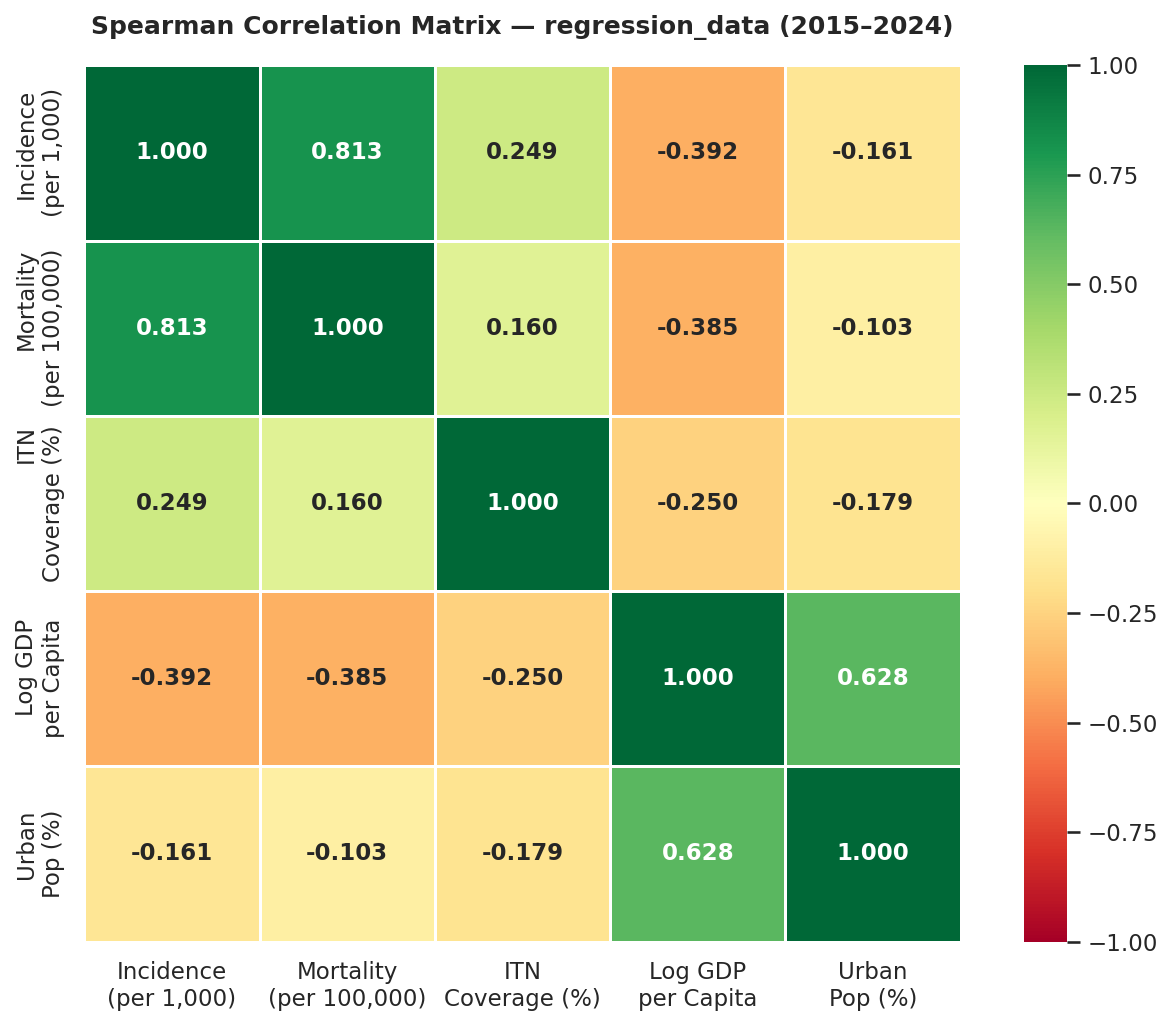

✓ Chart saved


In [13]:
# Correlation heatmap — all continuous variables in regression_data
# Shows direction and strength of relationships before formal testing
# log_gdp used instead of raw GDP

corr_vars = [
    'incidence_per_1000',
    'mortality_per_100k',
    'itn_coverage_pct',
    'log_gdp',
    'urban_pct'
]

corr_labels = {
    'incidence_per_1000' : 'Incidence\n(per 1,000)',
    'mortality_per_100k' : 'Mortality\n(per 100,000)',
    'itn_coverage_pct'   : 'ITN\nCoverage (%)',
    'log_gdp'            : 'Log GDP\nper Capita',
    'urban_pct'          : 'Urban\nPop (%)'
}

corr_data = regression_df[corr_vars].rename(columns=corr_labels)
corr_matrix = corr_data.corr(method='spearman')

fig, ax = plt.subplots(figsize=(9, 7))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix,
    annot      = True,
    fmt        = '.3f',
    cmap       = 'RdYlGn',
    center     = 0,
    vmin       = -1,
    vmax       = 1,
    square     = True,
    linewidths = 0.5,
    ax         = ax,
    annot_kws  = {'size': 11, 'weight': 'bold'}
)

ax.set_title('Spearman Correlation Matrix — regression_data (2015–2024)',
             fontweight='bold', fontsize=12, pad=15)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, '06_correlation_heatmap.png'),
            bbox_inches='tight', dpi=150)
plt.show()
print("✓ Chart saved")

### Correlation analysis findings

**Key observations:**

- ITN coverage shows a **positive** correlation with both incidence 
  (+0.249) and mortality (+0.160) — counter-intuitive but expected
  This reflects **targeting bias**: highest-burden countries received 
  most ITNs. Simple correlation cannot isolate the ITN effect.
  Multiple regression controlling for GDP and urbanisation is required.

- **Log GDP** is the strongest predictor in bivariate analysis
  (incidence: -0.392, mortality: -0.385) — confirming economic 
  capacity as a critical confounder

- **Incidence and mortality** correlate strongly (0.813) — 
  both outcomes track the same underlying transmission dynamics

- **Log GDP and urban population** correlate at 0.628 — 
  moderate multicollinearity risk, VIF to be checked in regression

- The positive ITN-burden correlation is the central analytical 
  challenge this project addresses — only regression with appropriate 
  controls can reveal the true intervention effect

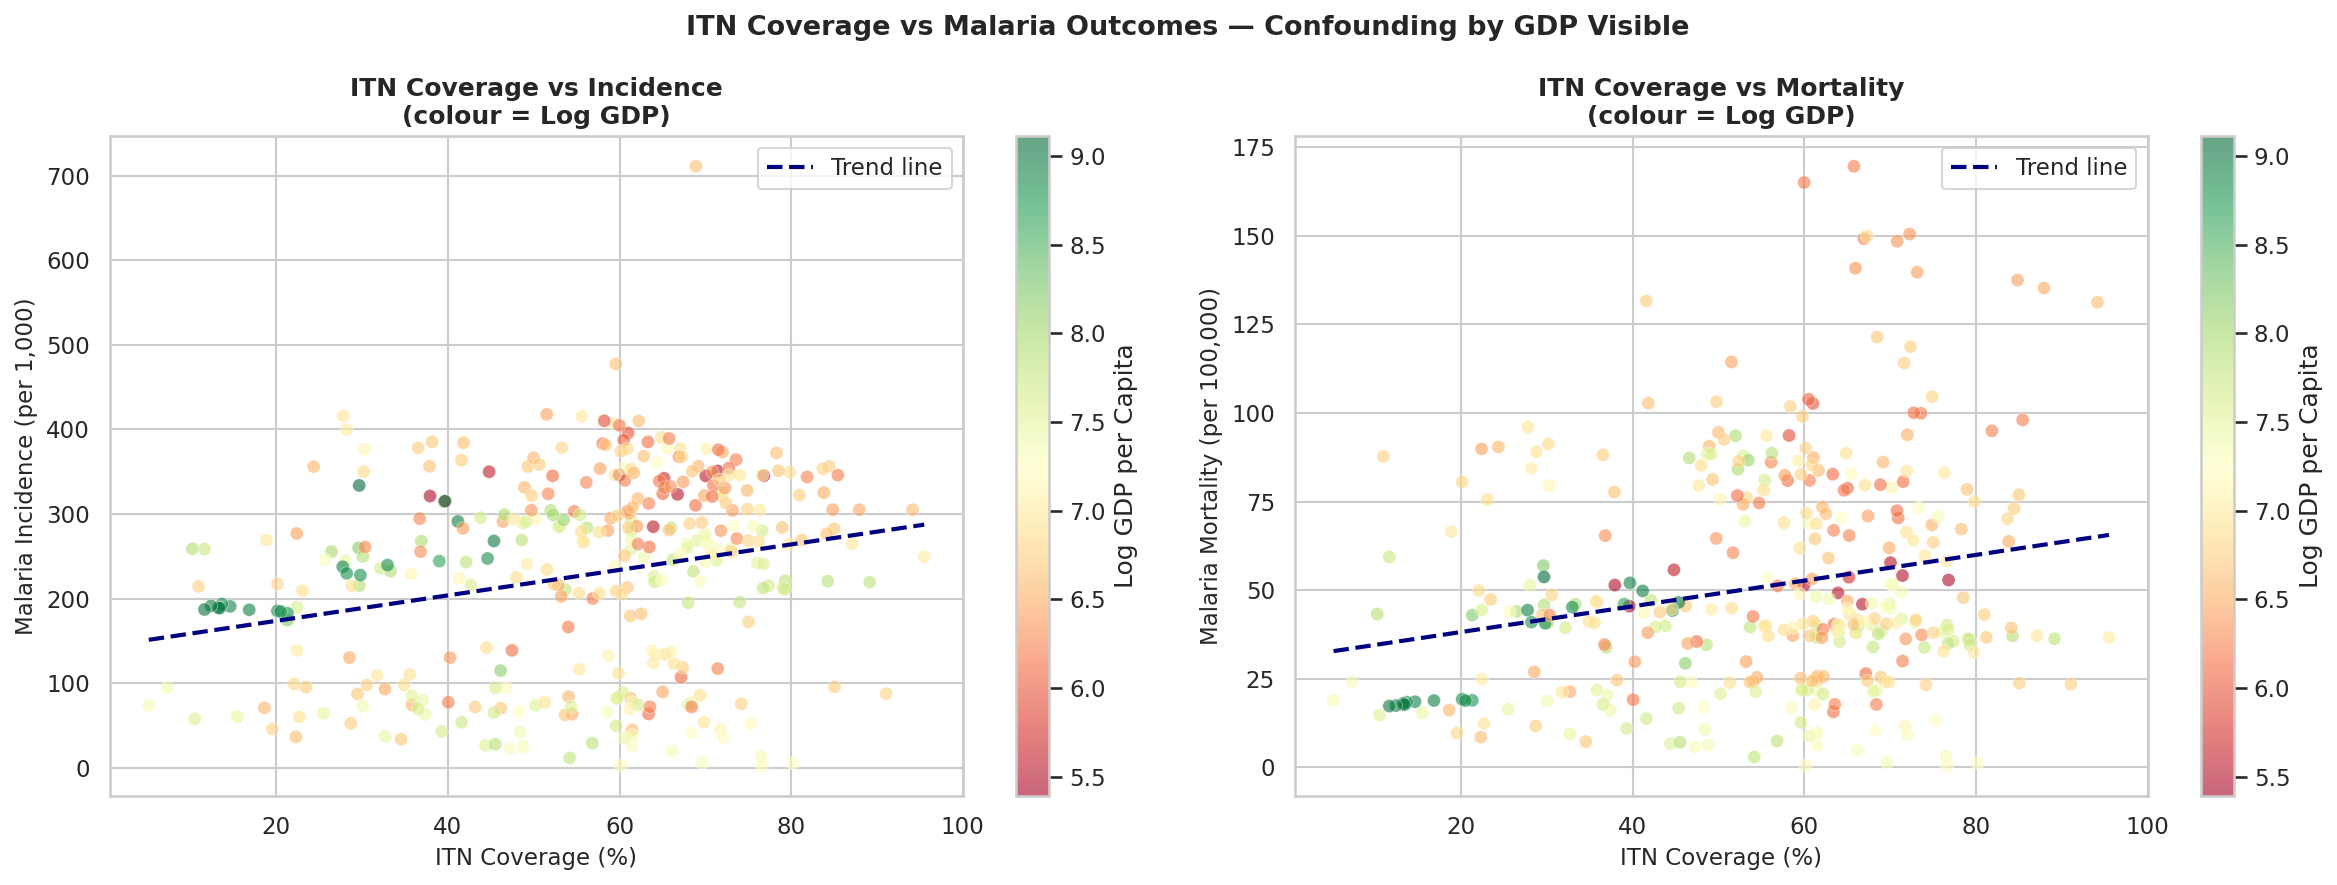

✓ Chart saved


In [14]:
# Scatter plot — ITN coverage vs malaria incidence
# Colour coded by log GDP to show confounding effect
# This visualises why simple correlation misleads

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left — ITN vs Incidence coloured by GDP
scatter1 = axes[0].scatter(
    regression_df['itn_coverage_pct'],
    regression_df['incidence_per_1000'],
    c     = regression_df['log_gdp'],
    cmap  = 'RdYlGn',
    alpha = 0.6,
    s     = 40,
    edgecolors = 'white',
    linewidth  = 0.3
)

# Add regression line
from numpy.polynomial import polynomial as P
clean = regression_df[['itn_coverage_pct',
                        'incidence_per_1000']].dropna()
z = np.polyfit(clean['itn_coverage_pct'],
               clean['incidence_per_1000'], 1)
p = np.poly1d(z)
x_line = np.linspace(clean['itn_coverage_pct'].min(),
                     clean['itn_coverage_pct'].max(), 100)
axes[0].plot(x_line, p(x_line), color='navy',
             linewidth=2, linestyle='--', label='Trend line')

plt.colorbar(scatter1, ax=axes[0], label='Log GDP per Capita')
axes[0].set_xlabel('ITN Coverage (%)', fontsize=11)
axes[0].set_ylabel('Malaria Incidence (per 1,000)', fontsize=11)
axes[0].set_title('ITN Coverage vs Incidence\n(colour = Log GDP)',
                  fontweight='bold')
axes[0].legend()

# Right — ITN vs Mortality coloured by GDP
scatter2 = axes[1].scatter(
    regression_df['itn_coverage_pct'],
    regression_df['mortality_per_100k'],
    c     = regression_df['log_gdp'],
    cmap  = 'RdYlGn',
    alpha = 0.6,
    s     = 40,
    edgecolors = 'white',
    linewidth  = 0.3
)

clean2 = regression_df[['itn_coverage_pct',
                         'mortality_per_100k']].dropna()
z2 = np.polyfit(clean2['itn_coverage_pct'],
                clean2['mortality_per_100k'], 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(clean2['itn_coverage_pct'].min(),
                      clean2['itn_coverage_pct'].max(), 100)
axes[1].plot(x_line2, p2(x_line2), color='navy',
             linewidth=2, linestyle='--', label='Trend line')

plt.colorbar(scatter2, ax=axes[1], label='Log GDP per Capita')
axes[1].set_xlabel('ITN Coverage (%)', fontsize=11)
axes[1].set_ylabel('Malaria Mortality (per 100,000)', fontsize=11)
axes[1].set_title('ITN Coverage vs Mortality\n(colour = Log GDP)',
                  fontweight='bold')
axes[1].legend()

plt.suptitle('ITN Coverage vs Malaria Outcomes — Confounding by GDP Visible',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, '07_itn_vs_outcomes_scatter.png'),
            bbox_inches='tight', dpi=150)
plt.show()
print("✓ Chart saved")

### ITN-outcome scatter findings

The scatter plots reveal the **confounding structure** of this dataset:

- The positive trend line (higher ITN → higher burden) is driven by 
  **targeting bias** — the poorest, highest-burden countries 
  (red/orange dots) received the most ITNs precisely because 
  they needed them most

- Richer countries (green dots) cluster at low ITN coverage 
  and low burden — their economic capacity reduces malaria 
  independently of bed net programmes

- The colour gradient from bottom-left (green, low burden, 
  moderate ITN) to top-right (red, high burden, high ITN) 
  visually demonstrates why GDP must be controlled for 
  in regression

- **Simple correlation cannot answer the research question** — 
  only regression controlling for GDP, urbanisation, and 
  other interventions can isolate the true ITN effect

## 5. ITN Scale-Up Classification

Countries classified into High, Medium, and Low ITN scale-up groups
based on change in ITN coverage between 2015 and 2023.
This grouping variable is used in Analysis 3 — comparing malaria
burden trajectories across countries with different intervention intensity.

In [15]:
# Classify countries by ITN scale-up intensity
# Scale-up = change in ITN coverage from 2015 to most recent year
# Uses regression_data — intervention period only

# Get ITN coverage for first and last available year per country
itn_first = (
    regression_df
    .sort_values('year')
    .groupby('country_code')
    .agg(
        itn_2015      = ('itn_coverage_pct', 'first'),
        itn_latest    = ('itn_coverage_pct', 'last'),
        latest_year   = ('year', 'last'),
        sub_region    = ('sub_region', 'first')
    )
    .reset_index()
    .dropna(subset=['itn_2015', 'itn_latest'])
)

# Calculate absolute change in ITN coverage
itn_first['itn_change'] = itn_first['itn_latest'] - itn_first['itn_2015']

# Classify into three groups based on change
# Thresholds based on distribution of change values
itn_first['scale_up_group'] = pd.cut(
    itn_first['itn_change'],
    bins   = [-100, -5, 10, 100],
    labels = ['Low/Decline', 'Stable', 'High Scale-Up']
)

print("ITN scale-up classification:\n")
print(itn_first[['country_code', 'sub_region', 'itn_2015',
                  'itn_latest', 'itn_change',
                  'scale_up_group']].to_string(index=False))

print(f"\nGroup distribution:")
print(itn_first['scale_up_group'].value_counts())

ITN scale-up classification:

country_code sub_region  itn_2015  itn_latest  itn_change scale_up_group
         AGO    Central 21.291318   10.210375  -11.080943    Low/Decline
         BDI       East 63.921443   39.597073  -24.324370    Low/Decline
         BEN       West 64.884553   60.515217   -4.369336         Stable
         BFA       West 51.501609   61.379781    9.878172         Stable
         CAF    Central 58.219765   81.860989   23.641223  High Scale-Up
         CIV       West 76.076226   36.896915  -39.179311    Low/Decline
         CMR    Central 55.630270   67.906586   12.276316  High Scale-Up
         COD    Central 54.725145   69.880841   15.155696  High Scale-Up
         COG    Central 53.679504   79.291121   25.611617  High Scale-Up
         COM       East 60.138495   37.394933  -22.743562    Low/Decline
         ERI       East 32.795382   38.972462    6.177079         Stable
         ETH       East 40.242843   22.404695  -17.838148    Low/Decline
         GAB    Centr

In [16]:
# Merge scale-up group back into regression_data
regression_df = regression_df.merge(
    itn_first[['country_code', 'itn_change', 'scale_up_group']],
    on  = 'country_code',
    how = 'left'
)

# Compare mean burden by scale-up group
scaleup_comparison = (
    regression_df
    .groupby('scale_up_group')
    .agg(
        mean_incidence  = ('incidence_per_1000', 'mean'),
        mean_mortality  = ('mortality_per_100k', 'mean'),
        mean_itn        = ('itn_coverage_pct', 'mean'),
        country_count   = ('country_code', 'nunique')
    )
    .reset_index()
)

print("Burden comparison by ITN scale-up group:\n")
print(scaleup_comparison.round(2).to_string(index=False))

Burden comparison by ITN scale-up group:

scale_up_group  mean_incidence  mean_mortality  mean_itn  country_count
   Low/Decline          178.43           34.31     47.06             11
        Stable          224.99           44.50     54.42              9
 High Scale-Up          257.92           64.94     60.34             17


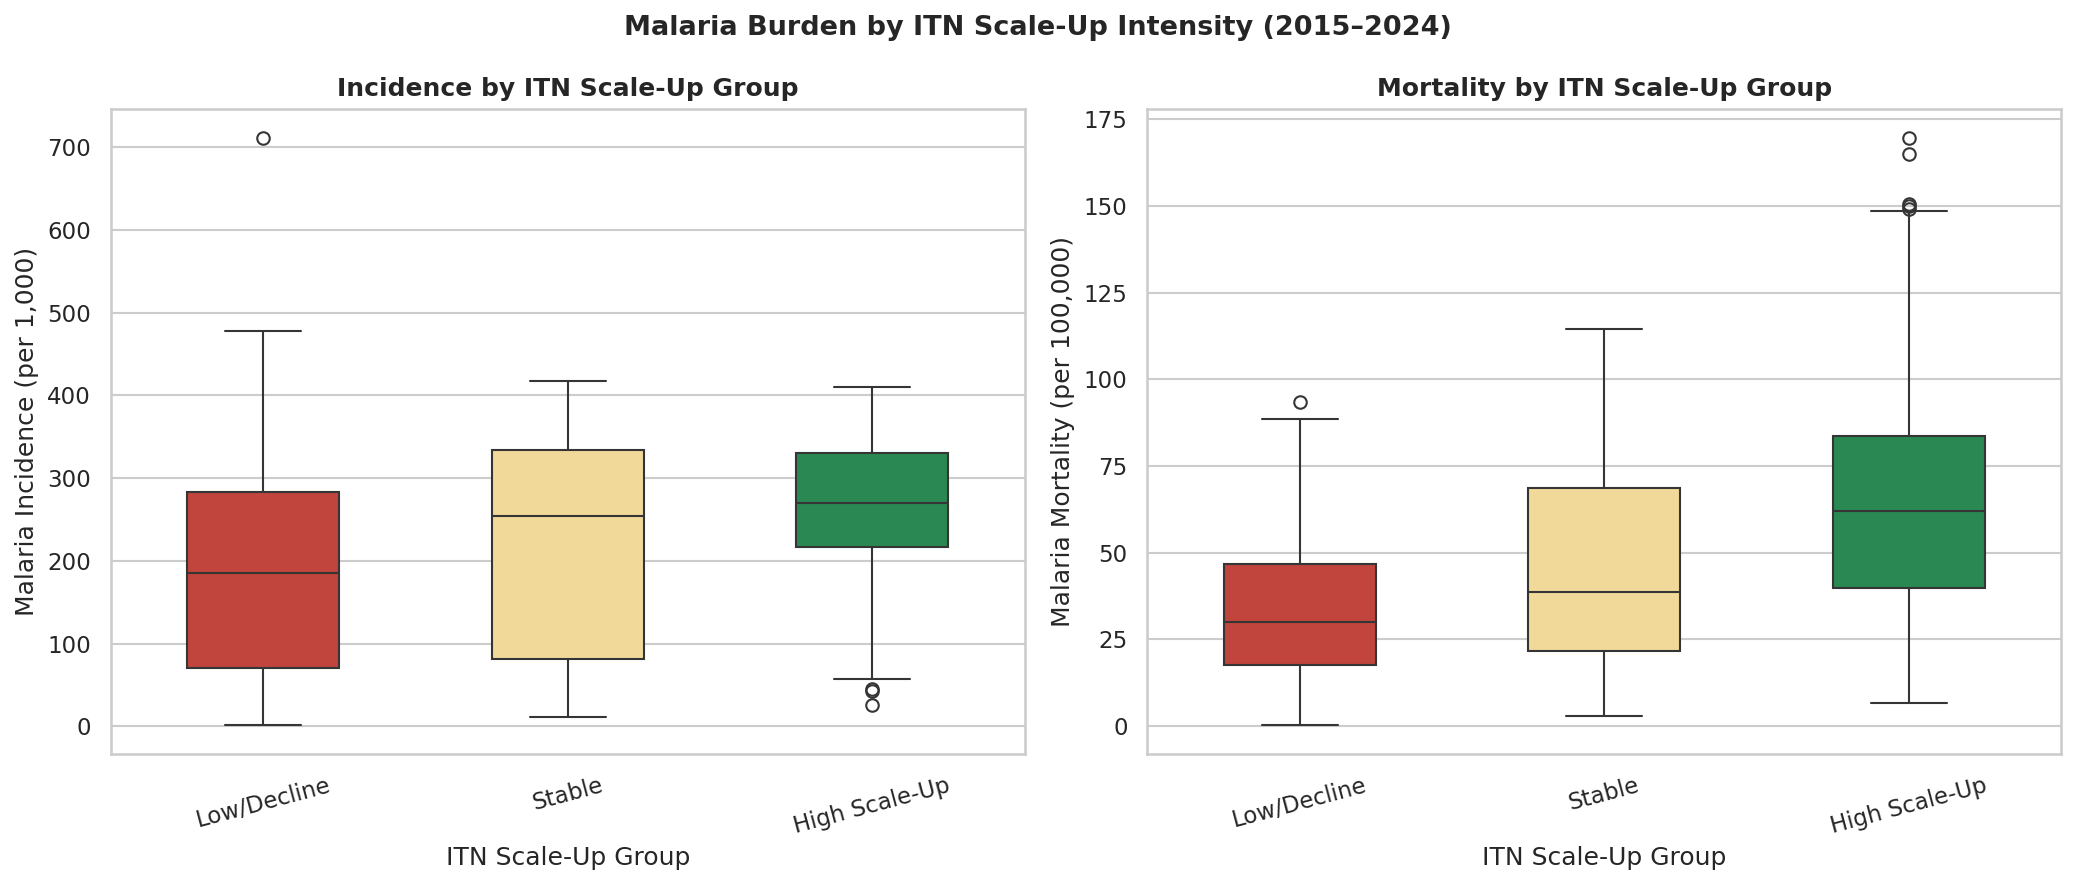

✓ Chart saved


In [17]:
# Visualise burden by scale-up group
# Box plots show distribution not just mean
# Answers: do high scale-up countries have lower burden?

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

group_order  = ['Low/Decline', 'Stable', 'High Scale-Up']
group_colors = ['#d73027', '#fee08b', '#1a9850']

sns.boxplot(
    data   = regression_df,
    x      = 'scale_up_group',
    y      = 'incidence_per_1000',
    order  = group_order,
    palette= group_colors,
    ax     = axes[0],
    width  = 0.5
)
axes[0].set_title('Incidence by ITN Scale-Up Group',
                  fontweight='bold')
axes[0].set_xlabel('ITN Scale-Up Group')
axes[0].set_ylabel('Malaria Incidence (per 1,000)')
axes[0].tick_params(axis='x', rotation=15)

sns.boxplot(
    data   = regression_df,
    x      = 'scale_up_group',
    y      = 'mortality_per_100k',
    order  = group_order,
    palette= group_colors,
    ax     = axes[1],
    width  = 0.5
)
axes[1].set_title('Mortality by ITN Scale-Up Group',
                  fontweight='bold')
axes[1].set_xlabel('ITN Scale-Up Group')
axes[1].set_ylabel('Malaria Mortality (per 100,000)')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Malaria Burden by ITN Scale-Up Intensity (2015–2024)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, '08_burden_by_scaleup_group.png'),
            bbox_inches='tight', dpi=150)
plt.show()
print("✓ Chart saved")

### ITN scale-up findings

Counter-intuitively, High Scale-Up countries show **higher** burden 
than Low/Decline countries — consistent with earlier correlation findings.

**Explanation — deliberate targeting:**

Countries with steepest ITN scale-up (SSD, MRT, TCD, NER) started 
from positions of extreme poverty and highest transmission intensity.
They received the most nets precisely because they needed them most.

Countries showing ITN decline (RWA, SEN, CIV) largely have 
improving health systems and declining burden — reduced ITN deployment
reflects successful transmission control, not programme failure.

**Key cases:**
- South Sudan: 18% → 65% coverage — conflict-affected, extreme burden
- Niger: 60% → 94% coverage — poorest country globally by HDI  
- Rwanda: 62% → 51% decline — strong health system, near-elimination trajectory

**Analytical implication:**
Descriptive group comparisons cannot answer the research question.
Regression controlling for baseline economic conditions and 
health system capacity is required to isolate the ITN effect.
This analysis is presented in Notebook 03.

## 6. EDA Summary — Key Findings

### What the data shows before formal modelling

**Burden trajectory (2000–2024)**
- Malaria incidence declined 40% across sub-Saharan Africa
- Malaria mortality declined 65% — faster than incidence
- Progress slowed after 2015 — COVID disruption visible 2020–2021
- West and Central Africa carry disproportionate remaining burden

**Regional heterogeneity**
- Five distinct sub-regional profiles — not one Africa story
- East Africa shows fastest decline — consistent with aggressive ITN programmes
- Southern Africa near-elimination by 2010 — health system and economic effect
- Regional variation justifies sub-region as regression control variable

**Variable distributions**
- GDP per capita severely right-skewed — log transformation applied
- ITN coverage approximately normal — no transformation needed
- High standard deviations throughout — substantial cross-country variation

**Correlation structure**
- ITN coverage positively correlated with burden — targeting bias confirmed
- GDP per capita strongest bivariate predictor of both outcomes
- GDP and urban population moderately collinear (r=0.628) — VIF check needed

**Central analytical challenge**
- Simple correlation and group comparisons cannot answer the research question
- Poorest highest-burden countries received most ITNs by design
- Multiple regression controlling for GDP, urbanisation, and interventions
  is required to isolate the true ITN effect
- This is addressed in Notebook 03

### Variables entering regression analysis
| Variable | Role | Transformation |
|----------|------|----------------|
| incidence_per_1000 | Outcome 1 | None |
| mortality_per_100k | Outcome 2 | None |
| itn_coverage_pct | Main predictor | None |
| irs_deployed | Control — binary | None |
| act_deployed | Control — binary | None |
| log_gdp | Control — economic | Log applied |
| urban_pct | Control — demographic | None |

In [18]:
# Save updated regression_df with scale-up groups and log_gdp
# This is the final version used in Notebook 03

regression_df.to_csv(
    os.path.join(CLEANED_PATH, 'regression_data_final.csv'),
    index=False
)

trend_df.to_csv(
    os.path.join(CLEANED_PATH, 'trend_data_final.csv'),
    index=False
)

print("✓ Final analytical datasets saved")
print(f"  regression_data_final.csv  — {len(regression_df)} rows, "
      f"{len(regression_df.columns)} columns")
print(f"  trend_data_final.csv       — {len(trend_df)} rows, "
      f"{len(trend_df.columns)} columns")
print(f"\nColumns in regression_data_final:")
print(regression_df.columns.tolist())

✓ Final analytical datasets saved
  regression_data_final.csv  — 371 rows, 14 columns
  trend_data_final.csv       — 1123 rows, 13 columns

Columns in regression_data_final:
['country_code', 'region', 'year', 'incidence_per_1000', 'mortality_per_100k', 'itn_coverage_pct', 'irs_deployed', 'act_deployed', 'gdp_per_capita', 'urban_pct', 'log_gdp', 'sub_region', 'itn_change', 'scale_up_group']
